# Publication-Ready Figures: Experimental Results and Ablations (Chapter 6)

This notebook generates the publication-ready figures for Chapter 6 ('Experimental Results and Ablations') conforming to the BeautifulFigures style rules:
1. **Figure 1: Cross-Validation & Test Distributions** (`fig1_cv_and_test_distributions.pdf`)
2. **Figure 2: Multi-Seed ROC and Precision-Recall Curves** (`fig2_roc_and_pr_curves.pdf`)
3. **Figure 3: Multi-Seed Confusion Matrices Grid** (`fig3_confusion_matrices.pdf`)
4. **Figure 4: Probability Calibration & Brier Scores** (`fig4_probability_calibration.pdf`)
5. **Figure 5: Parameter Efficiency Frontier & Multi-Metric Profile** (`fig5_param_efficiency_frontier.pdf`)
6. **Latent Space UMAP Projection with Disease Axis** (`latent_space.pdf`)


In [1]:
import os, sys, glob, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, brier_score_loss, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# Global publication style settings
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

MM = 1 / 25.4

# Two-hue Teal / Purple publication palette
COLOR_GELSTM_FILL, COLOR_GELSTM_EDGE = '#2ba099', '#14605b'      # Teal
COLOR_BTGT_FILL, COLOR_BTGT_EDGE = '#873397', '#50165b'          # Purple

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
OUTPUT_DIRS = [
    _REPO_ROOT / 'THESIS' / 'figures',
    _REPO_ROOT / 'DOCS' / 'results' / 'figures',
]
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Environment initialized and output directories ready.')


✓ Environment initialized and output directories ready.


In [2]:
# Ingest benchmark runs
gelstm_summaries = [
    _REPO_ROOT / 'CLASSIFIER' / 'outputs' / 'recon-ablation-gelstm-pretrained-frozen-2to3v-seed42' / 'runs' / 'serene-morning-1-5e33e2170-2026-08-21_19-43-08' / 'run_summary.json',
    _REPO_ROOT / 'CLASSIFIER' / 'outputs' / 'recon-ablation-gelstm-pretrained-frozen-2to3v-seed43' / 'runs' / 'zesty-wind-1-5e33e2170-2026-08-21_19-57-54' / 'run_summary.json',
    _REPO_ROOT / 'CLASSIFIER' / 'outputs' / 'recon-ablation-gelstm-pretrained-frozen-2to3v-seed44' / 'runs' / 'kind-water-2-5e33e2170-2026-08-22_09-29-50' / 'run_summary.json',
    _REPO_ROOT / 'CLASSIFIER' / 'outputs' / 'recon-ablation-gelstm-pretrained-frozen-2to3v-seed45' / 'runs' / 'sunny-light-1-5e33e2170-2026-08-22_09-44-52' / 'run_summary.json'
]

bt_summaries = [
    _REPO_ROOT / 'BRAINTOKENGT' / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized' / 'runs' / 'crimson-morning-8-5e33e2170-2026-08-21_18-47-20' / 'run_summary.json',
    _REPO_ROOT / 'BRAINTOKENGT' / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed43' / 'runs' / 'ruby-cloud-1-5e33e2170-2026-08-21_19-02-53' / 'run_summary.json',
    _REPO_ROOT / 'BRAINTOKENGT' / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed44' / 'runs' / 'royal-canyon-1-5e33e2170-2026-08-21_19-16-27' / 'run_summary.json',
    _REPO_ROOT / 'BRAINTOKENGT' / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed45' / 'runs' / 'mild-frost-1-5e33e2170-2026-08-21_19-28-56' / 'run_summary.json'
]

seeds = [42, 43, 44, 45]
gelstm_runs = []
bt_runs = []
seed_records = []
fold_records = []

for i, seed in enumerate(seeds):
    with open(gelstm_summaries[i], 'r') as f:
        g_data = json.load(f)
    gelstm_runs.append(g_data)
    
    with open(bt_summaries[i], 'r') as f:
        b_data = json.load(f)
    bt_runs.append(b_data)
    
    g_test_auc = g_data['metrics']['test_auc']
    g_test_f1 = g_data['metrics']['test_f1']
    g_cv_auc = np.mean(g_data['cv_results']['val_auc'])
    g_test_sens = g_data['metrics']['test_sensitivity']
    g_test_spec = g_data['metrics']['test_specificity']
    g_th = g_data['metrics']['threshold']
    g_brier = brier_score_loss(g_data['test_labels'], g_data['test_probabilities'])
    
    b_test_auc = b_data['metrics']['test_auc']
    b_test_f1 = b_data['metrics']['test_f1']
    b_cv_auc = np.mean(b_data['cv_results']['val_auc'])
    b_test_sens = b_data['metrics']['test_sensitivity']
    b_test_spec = b_data['metrics']['test_specificity']
    b_th = b_data['metrics']['threshold']
    b_brier = brier_score_loss(b_data['test_labels'], b_data['test_probabilities'])
    
    seed_records.append({
        'Seed': seed,
        'GELSTM Test AUC': g_test_auc,
        'GELSTM Test F1': g_test_f1,
        'GELSTM CV AUC': g_cv_auc,
        'GELSTM Sens': g_test_sens,
        'GELSTM Spec': g_test_spec,
        'GELSTM Brier': g_brier,
        'GELSTM Threshold': g_th,
        'BrainTokenGT Test AUC': b_test_auc,
        'BrainTokenGT Test F1': b_test_f1,
        'BrainTokenGT CV AUC': b_cv_auc,
        'BrainTokenGT Sens': b_test_sens,
        'BrainTokenGT Spec': b_test_spec,
        'BrainTokenGT Brier': b_brier,
        'BrainTokenGT Threshold': b_th,
    })
    
    for fold_idx in range(5):
        fold_records.append({
            'Seed': seed,
            'Fold': fold_idx + 1,
            'Model': 'GELSTM (Frozen GAAE)',
            'CV Val AUC': g_data['cv_results']['val_auc'][fold_idx],
            'CV Val F1': g_data['cv_results']['val_f1'][fold_idx],
        })
        fold_records.append({
            'Seed': seed,
            'Fold': fold_idx + 1,
            'Model': 'BrainTokenGT (Stabilized)',
            'CV Val AUC': b_data['cv_results']['val_auc'][fold_idx],
            'CV Val F1': b_data['cv_results']['val_f1'][fold_idx],
        })

df_seeds = pd.DataFrame(seed_records)
df_folds = pd.DataFrame(fold_records)

print(f'✓ Loaded {len(df_seeds)} main seeds and {len(df_folds)} fold pairs.')


✓ Loaded 4 main seeds and 40 fold pairs.


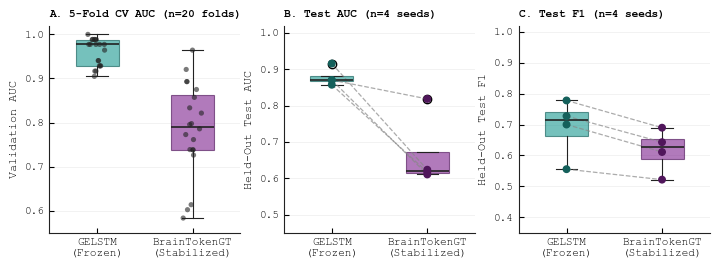

✓ Figure 1 saved successfully.


In [3]:
# -------------------------------------------------------------
# Figure 1: CV and Test Distributions
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(180 * MM, 65 * MM))

# Panel A: 5-Fold CV AUC Distribution (n=20 folds)
box1 = axes[0].boxplot(
    [df_folds[df_folds['Model'] == 'GELSTM (Frozen GAAE)']['CV Val AUC'],
     df_folds[df_folds['Model'] == 'BrainTokenGT (Stabilized)']['CV Val AUC']],
    positions=[0, 1], widths=0.45, patch_artist=True,
    boxprops=dict(facecolor=COLOR_GELSTM_FILL, edgecolor=COLOR_GELSTM_EDGE, alpha=0.65, linewidth=0.8),
    medianprops=dict(color='#222222', linewidth=1.2),
    whiskerprops=dict(color='#222222', linewidth=0.8),
    capprops=dict(color='#222222', linewidth=0.8)
)
box1['boxes'][1].set_facecolor(COLOR_BTGT_FILL)
box1['boxes'][1].set_edgecolor(COLOR_BTGT_EDGE)

np.random.seed(42)
for i, m in enumerate(['GELSTM (Frozen GAAE)', 'BrainTokenGT (Stabilized)']):
    y = df_folds[df_folds['Model'] == m]['CV Val AUC'].values
    x = np.random.normal(i, 0.05, size=len(y))
    axes[0].scatter(x, y, color='#222222', s=14, alpha=0.6, zorder=3, edgecolors='none')

axes[0].set_title('A. 5-Fold CV AUC (n=20 folds)', fontsize=8, fontweight='bold', loc='left')
axes[0].set_ylabel('Validation AUC')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['GELSTM\n(Frozen)', 'BrainTokenGT\n(Stabilized)'])
axes[0].set_ylim(0.55, 1.02)

# Panel B: Held-Out Test AUC Across Seeds
box2 = axes[1].boxplot(
    [df_seeds['GELSTM Test AUC'], df_seeds['BrainTokenGT Test AUC']],
    positions=[0, 1], widths=0.45, patch_artist=True,
    boxprops=dict(facecolor=COLOR_GELSTM_FILL, edgecolor=COLOR_GELSTM_EDGE, alpha=0.65, linewidth=0.8),
    medianprops=dict(color='#222222', linewidth=1.2),
    whiskerprops=dict(color='#222222', linewidth=0.8),
    capprops=dict(color='#222222', linewidth=0.8)
)
box2['boxes'][1].set_facecolor(COLOR_BTGT_FILL)
box2['boxes'][1].set_edgecolor(COLOR_BTGT_EDGE)

for seed in seeds:
    row = df_seeds[df_seeds['Seed'] == seed]
    g_val, b_val = row['GELSTM Test AUC'].values[0], row['BrainTokenGT Test AUC'].values[0]
    axes[1].plot([0, 1], [g_val, b_val], color='#888888', linestyle='--', alpha=0.7, lw=0.9, zorder=2)
    axes[1].scatter([0, 1], [g_val, b_val], color=['#14605b', '#50165b'], s=22, zorder=3)

axes[1].set_title('B. Test AUC (n=4 seeds)', fontsize=8, fontweight='bold', loc='left')
axes[1].set_ylabel('Held-Out Test AUC')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['GELSTM\n(Frozen)', 'BrainTokenGT\n(Stabilized)'])
axes[1].set_ylim(0.45, 1.02)

# Panel C: Held-Out Test F1 Across Seeds
box3 = axes[2].boxplot(
    [df_seeds['GELSTM Test F1'], df_seeds['BrainTokenGT Test F1']],
    positions=[0, 1], widths=0.45, patch_artist=True,
    boxprops=dict(facecolor=COLOR_GELSTM_FILL, edgecolor=COLOR_GELSTM_EDGE, alpha=0.65, linewidth=0.8),
    medianprops=dict(color='#222222', linewidth=1.2),
    whiskerprops=dict(color='#222222', linewidth=0.8),
    capprops=dict(color='#222222', linewidth=0.8)
)
box3['boxes'][1].set_facecolor(COLOR_BTGT_FILL)
box3['boxes'][1].set_edgecolor(COLOR_BTGT_EDGE)

for seed in seeds:
    row = df_seeds[df_seeds['Seed'] == seed]
    g_val, b_val = row['GELSTM Test F1'].values[0], row['BrainTokenGT Test F1'].values[0]
    axes[2].plot([0, 1], [g_val, b_val], color='#888888', linestyle='--', alpha=0.7, lw=0.9, zorder=2)
    axes[2].scatter([0, 1], [g_val, b_val], color=['#14605b', '#50165b'], s=22, zorder=3)

axes[2].set_title('C. Test F1 (n=4 seeds)', fontsize=8, fontweight='bold', loc='left')
axes[2].set_ylabel('Held-Out Test F1')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['GELSTM\n(Frozen)', 'BrainTokenGT\n(Stabilized)'])
axes[2].set_ylim(0.35, 1.02)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('#222222')
    ax.spines['bottom'].set_color('#222222')
    ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
    ax.set_axisbelow(True)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig1_cv_and_test_distributions.pdf')
    fig.savefig(out_dir / 'fig1_cv_and_test_distributions.png', dpi=600)

plt.show()
print('✓ Figure 1 saved successfully.')


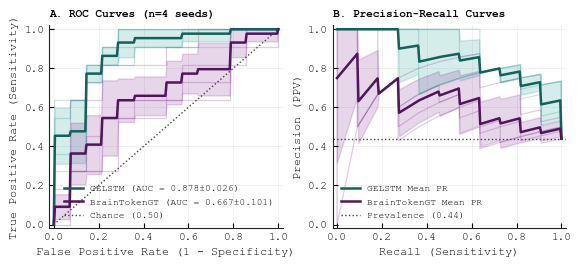

✓ Figure 2 saved successfully.


In [4]:
# -------------------------------------------------------------
# Figure 2: Multi-Seed ROC & Precision-Recall Curves
# -------------------------------------------------------------
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(145 * MM, 65 * MM))

mean_fpr = np.linspace(0, 1, 200)
mean_recall = np.linspace(0, 1, 200)
g_tprs, b_tprs = [], []
g_precisions, b_precisions = [], []

for i, seed in enumerate(seeds):
    y_true_g = gelstm_runs[i]['test_labels']
    y_prob_g = gelstm_runs[i]['test_probabilities']
    fpr_g, tpr_g, _ = roc_curve(y_true_g, y_prob_g)
    interp_tpr_g = np.interp(mean_fpr, fpr_g, tpr_g)
    interp_tpr_g[0] = 0.0
    g_tprs.append(interp_tpr_g)
    
    prec_g, rec_g, _ = precision_recall_curve(y_true_g, y_prob_g)
    interp_prec_g = np.interp(mean_recall, rec_g[::-1], prec_g[::-1])
    g_precisions.append(interp_prec_g)
    
    ax_roc.plot(fpr_g, tpr_g, color=COLOR_GELSTM_FILL, alpha=0.25, lw=0.9)
    ax_pr.plot(rec_g, prec_g, color=COLOR_GELSTM_FILL, alpha=0.25, lw=0.9)
    
    y_true_b = bt_runs[i]['test_labels']
    y_prob_b = bt_runs[i]['test_probabilities']
    fpr_b, tpr_b, _ = roc_curve(y_true_b, y_prob_b)
    interp_tpr_b = np.interp(mean_fpr, fpr_b, tpr_b)
    interp_tpr_b[0] = 0.0
    b_tprs.append(interp_tpr_b)
    
    prec_b, rec_b, _ = precision_recall_curve(y_true_b, y_prob_b)
    interp_prec_b = np.interp(mean_recall, rec_b[::-1], prec_b[::-1])
    b_precisions.append(interp_prec_b)
    
    ax_roc.plot(fpr_b, tpr_b, color=COLOR_BTGT_FILL, alpha=0.25, lw=0.9)
    ax_pr.plot(rec_b, prec_b, color=COLOR_BTGT_FILL, alpha=0.25, lw=0.9)

mean_tpr_g = np.mean(g_tprs, axis=0)
mean_tpr_g[-1] = 1.0
std_tpr_g = np.std(g_tprs, axis=0)
ax_roc.plot(mean_fpr, mean_tpr_g, color=COLOR_GELSTM_EDGE, lw=1.8,
            label=f'GELSTM (AUC = {np.mean(df_seeds["GELSTM Test AUC"]):.3f}±{np.std(df_seeds["GELSTM Test AUC"], ddof=1):.3f})')
ax_roc.fill_between(mean_fpr, np.maximum(0, mean_tpr_g - std_tpr_g), np.minimum(1, mean_tpr_g + std_tpr_g),
                    color=COLOR_GELSTM_FILL, alpha=0.2)

mean_tpr_b = np.mean(b_tprs, axis=0)
mean_tpr_b[-1] = 1.0
std_tpr_b = np.std(b_tprs, axis=0)
ax_roc.plot(mean_fpr, mean_tpr_b, color=COLOR_BTGT_EDGE, lw=1.8,
            label=f'BrainTokenGT (AUC = {np.mean(df_seeds["BrainTokenGT Test AUC"]):.3f}±{np.std(df_seeds["BrainTokenGT Test AUC"], ddof=1):.3f})')
ax_roc.fill_between(mean_fpr, np.maximum(0, mean_tpr_b - std_tpr_b), np.minimum(1, mean_tpr_b + std_tpr_b),
                    color=COLOR_BTGT_FILL, alpha=0.2)

ax_roc.plot([0, 1], [0, 1], linestyle=':', color='#444444', lw=1.0, label='Chance (0.50)')
ax_roc.set_xlim([-0.02, 1.02])
ax_roc.set_ylim([-0.02, 1.02])
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
ax_roc.set_ylabel('True Positive Rate (Sensitivity)')
ax_roc.set_title('A. ROC Curves (n=4 seeds)', fontsize=8, fontweight='bold', loc='left')
ax_roc.legend(loc='lower right', fontsize=6.8)

mean_prec_g = np.mean(g_precisions, axis=0)
std_prec_g = np.std(g_precisions, axis=0)
ax_pr.plot(mean_recall, mean_prec_g, color=COLOR_GELSTM_EDGE, lw=1.8, label='GELSTM Mean PR')
ax_pr.fill_between(mean_recall, np.maximum(0, mean_prec_g - std_prec_g), np.minimum(1, mean_prec_g + std_prec_g),
                   color=COLOR_GELSTM_FILL, alpha=0.2)

mean_prec_b = np.mean(b_precisions, axis=0)
std_prec_b = np.std(b_precisions, axis=0)
ax_pr.plot(mean_recall, mean_prec_b, color=COLOR_BTGT_EDGE, lw=1.8, label='BrainTokenGT Mean PR')
ax_pr.fill_between(mean_recall, np.maximum(0, mean_prec_b - std_prec_b), np.minimum(1, mean_prec_b + std_prec_b),
                   color=COLOR_BTGT_FILL, alpha=0.2)

prevalence = 11.0 / 25.0
ax_pr.axhline(prevalence, color='#444444', linestyle=':', lw=1.0, label=f'Prevalence ({prevalence:.2f})')
ax_pr.set_xlim([-0.02, 1.02])
ax_pr.set_ylim([-0.02, 1.02])
ax_pr.set_xlabel('Recall (Sensitivity)')
ax_pr.set_ylabel('Precision (PPV)')
ax_pr.set_title('B. Precision-Recall Curves', fontsize=8, fontweight='bold', loc='left')
ax_pr.legend(loc='lower left', fontsize=6.8)

for ax in (ax_roc, ax_pr):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('#222222')
    ax.spines['bottom'].set_color('#222222')
    ax.grid(linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
    ax.set_axisbelow(True)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig2_roc_and_pr_curves.pdf')
    fig.savefig(out_dir / 'fig2_roc_and_pr_curves.png', dpi=600)

plt.show()
print('✓ Figure 2 saved successfully.')


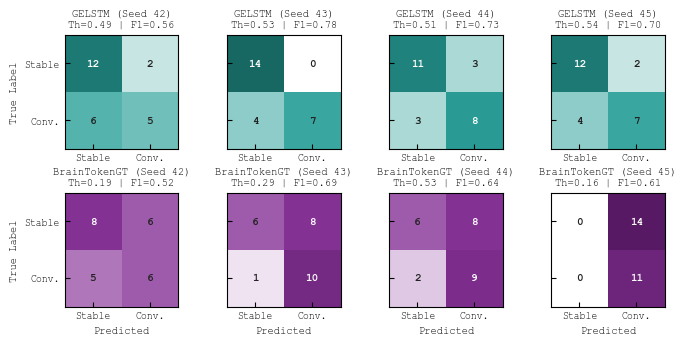

✓ Figure 3 saved successfully.


In [5]:
# -------------------------------------------------------------
# Figure 3: Multi-Seed Confusion Matrices Grid (2 x 4)
# -------------------------------------------------------------
from matplotlib.colors import LinearSegmentedColormap

teal_cmap = LinearSegmentedColormap.from_list('TealGrad', ['#ffffff', '#2ba099', '#14605b'], N=256)
purple_cmap = LinearSegmentedColormap.from_list('PurpleGrad', ['#ffffff', '#873397', '#50165b'], N=256)

fig, axes = plt.subplots(2, 4, figsize=(180 * MM, 85 * MM))
classes = ['Stable', 'Conv.']

for i, seed in enumerate(seeds):
    y_true_g = np.array(gelstm_runs[i]['test_labels'])
    y_prob_g = np.array(gelstm_runs[i]['test_probabilities'])
    th_g = gelstm_runs[i]['metrics']['threshold']
    y_pred_g = (y_prob_g >= th_g).astype(int)
    cm_g = confusion_matrix(y_true_g, y_pred_g)
    
    im_g = axes[0, i].imshow(cm_g, cmap=teal_cmap, vmin=0, vmax=15)
    axes[0, i].set_title(f'GELSTM (Seed {seed})\nTh={th_g:.2f} | F1={df_seeds.loc[i, "GELSTM Test F1"]:.2f}', fontsize=7.5)
    axes[0, i].set_xticks([0, 1])
    axes[0, i].set_yticks([0, 1])
    axes[0, i].set_xticklabels(classes, fontsize=7)
    axes[0, i].set_yticklabels(classes if i == 0 else ['', ''], fontsize=7)
    if i == 0:
        axes[0, i].set_ylabel('True Label', fontsize=7.5)
    for r in range(2):
        for c in range(2):
            val = cm_g[r, c]
            color = 'white' if val > 7 else '#222222'
            axes[0, i].text(c, r, str(val), ha='center', va='center', color=color, fontsize=8, fontweight='bold')
    
    y_true_b = np.array(bt_runs[i]['test_labels'])
    y_prob_b = np.array(bt_runs[i]['test_probabilities'])
    th_b = bt_runs[i]['metrics']['threshold']
    y_pred_b = (y_prob_b >= th_b).astype(int)
    cm_b = confusion_matrix(y_true_b, y_pred_b)
    
    im_b = axes[1, i].imshow(cm_b, cmap=purple_cmap, vmin=0, vmax=15)
    axes[1, i].set_title(f'BrainTokenGT (Seed {seed})\nTh={th_b:.2f} | F1={df_seeds.loc[i, "BrainTokenGT Test F1"]:.2f}', fontsize=7.5)
    axes[1, i].set_xticks([0, 1])
    axes[1, i].set_yticks([0, 1])
    axes[1, i].set_xticklabels(classes, fontsize=7)
    axes[1, i].set_yticklabels(classes if i == 0 else ['', ''], fontsize=7)
    axes[1, i].set_xlabel('Predicted', fontsize=7.5)
    if i == 0:
        axes[1, i].set_ylabel('True Label', fontsize=7.5)
    for r in range(2):
        for c in range(2):
            val = cm_b[r, c]
            color = 'white' if val > 7 else '#222222'
            axes[1, i].text(c, r, str(val), ha='center', va='center', color=color, fontsize=8, fontweight='bold')

for ax in axes.flat:
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['top'].set_linewidth(0.8)
    ax.spines['right'].set_linewidth(0.8)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig3_confusion_matrices.pdf')
    fig.savefig(out_dir / 'fig3_confusion_matrices.png', dpi=600)

plt.show()
print('✓ Figure 3 saved successfully.')


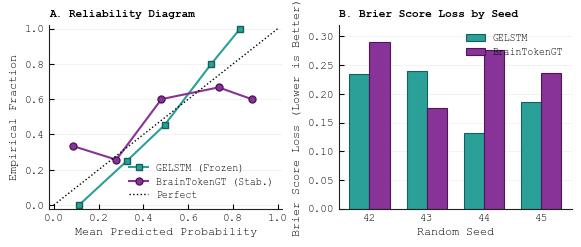

✓ Figure 4 saved successfully.


In [6]:
# -------------------------------------------------------------
# Figure 4: Calibration & Brier Score Comparison
# -------------------------------------------------------------
fig, (ax_cal, ax_brier) = plt.subplots(1, 2, figsize=(145 * MM, 60 * MM))

all_y_true_g = np.concatenate([r['test_labels'] for r in gelstm_runs])
all_y_prob_g = np.concatenate([r['test_probabilities'] for r in gelstm_runs])

all_y_true_b = np.concatenate([r['test_labels'] for r in bt_runs])
all_y_prob_b = np.concatenate([r['test_probabilities'] for r in bt_runs])

prob_true_g, prob_pred_g = calibration_curve(all_y_true_g, all_y_prob_g, n_bins=5, strategy='uniform')
prob_true_b, prob_pred_b = calibration_curve(all_y_true_b, all_y_prob_b, n_bins=5, strategy='uniform')

ax_cal.plot(prob_pred_g, prob_true_g, 's-', color=COLOR_GELSTM_FILL, mec=COLOR_GELSTM_EDGE, lw=1.5, ms=5, label='GELSTM (Frozen)')
ax_cal.plot(prob_pred_b, prob_true_b, 'o-', color=COLOR_BTGT_FILL, mec=COLOR_BTGT_EDGE, lw=1.5, ms=5, label='BrainTokenGT (Stab.)')
ax_cal.plot([0, 1], [0, 1], 'k:', lw=1.0, label='Perfect')

ax_cal.set_xlim([-0.02, 1.02])
ax_cal.set_ylim([-0.02, 1.02])
ax_cal.set_xlabel('Mean Predicted Probability')
ax_cal.set_ylabel('Empirical Fraction')
ax_cal.set_title('A. Reliability Diagram', fontsize=8, fontweight='bold', loc='left')
ax_cal.legend(loc='lower right', fontsize=7)

x = np.arange(len(seeds))
width = 0.35

ax_brier.bar(x - width/2, df_seeds['GELSTM Brier'], width, label='GELSTM',
             color=COLOR_GELSTM_FILL, edgecolor=COLOR_GELSTM_EDGE, linewidth=0.8)
ax_brier.bar(x + width/2, df_seeds['BrainTokenGT Brier'], width, label='BrainTokenGT',
             color=COLOR_BTGT_FILL, edgecolor=COLOR_BTGT_EDGE, linewidth=0.8)

ax_brier.set_xlabel('Random Seed')
ax_brier.set_ylabel('Brier Score Loss (Lower is Better)')
ax_brier.set_xticks(x)
ax_brier.set_xticklabels([str(s) for s in seeds])
ax_brier.set_ylim(0, 0.32)
ax_brier.set_title('B. Brier Score Loss by Seed', fontsize=8, fontweight='bold', loc='left')
ax_brier.legend(loc='upper right', fontsize=7)

for ax in (ax_cal, ax_brier):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('#222222')
    ax.spines['bottom'].set_color('#222222')
    ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
    ax.set_axisbelow(True)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig4_probability_calibration.pdf')
    fig.savefig(out_dir / 'fig4_probability_calibration.png', dpi=600)

plt.show()
print('✓ Figure 4 saved successfully.')


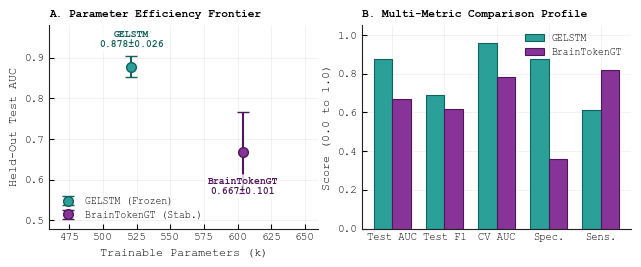

✓ Figure 5 saved successfully.


In [7]:
# -------------------------------------------------------------
# Figure 5: Parameter Efficiency Frontier & Multi-Metric Profile
# -------------------------------------------------------------
fig, (ax_param, ax_profile) = plt.subplots(1, 2, figsize=(160 * MM, 65 * MM))

ax_param.errorbar(
    520.905, np.mean(df_seeds['GELSTM Test AUC']),
    yerr=np.std(df_seeds['GELSTM Test AUC'], ddof=1),
    fmt='o', color=COLOR_GELSTM_FILL, mec=COLOR_GELSTM_EDGE, ecolor=COLOR_GELSTM_EDGE,
    elinewidth=1.5, capsize=4, ms=7, label='GELSTM (Frozen)'
)
# Part 8.1 bbox + 8.3 offset points: callout above error-bar cap (≥10 pt)
ax_param.annotate(
    f'GELSTM\n{np.mean(df_seeds["GELSTM Test AUC"]):.3f}\u00b1{np.std(df_seeds["GELSTM Test AUC"], ddof=1):.3f}',
    xy=(520.905, np.mean(df_seeds['GELSTM Test AUC'])),
    xytext=(0, 14), textcoords='offset points',
    ha='center', fontsize=7, color='#14605b', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.8),
    zorder=10,
)

ax_param.errorbar(
    603.849, np.mean(df_seeds['BrainTokenGT Test AUC']),
    yerr=np.std(df_seeds['BrainTokenGT Test AUC'], ddof=1),
    fmt='o', color=COLOR_BTGT_FILL, mec=COLOR_BTGT_EDGE, ecolor=COLOR_BTGT_EDGE,
    elinewidth=1.5, capsize=4, ms=7, label='BrainTokenGT (Stab.)'
)
# Part 8.1 bbox + 8.3 offset points: callout below error-bar cap (≥10 pt)
ax_param.annotate(
    f'BrainTokenGT\n{np.mean(df_seeds["BrainTokenGT Test AUC"]):.3f}\u00b1{np.std(df_seeds["BrainTokenGT Test AUC"], ddof=1):.3f}',
    xy=(603.849, np.mean(df_seeds['BrainTokenGT Test AUC'])),
    xytext=(0, -30), textcoords='offset points',
    ha='center', fontsize=7, color='#50165b', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.8),
    zorder=10,
)

ax_param.set_xlim(460, 660)
ax_param.set_ylim(0.48, 0.98)
ax_param.set_xlabel('Trainable Parameters (k)')
ax_param.set_ylabel('Held-Out Test AUC')
ax_param.set_title('A. Parameter Efficiency Frontier', fontsize=8, fontweight='bold', loc='left')
ax_param.legend(loc='lower left', fontsize=7)

metrics_labels = ['Test AUC', 'Test F1', 'CV AUC', 'Spec.', 'Sens.']
gelstm_metrics = [
    np.mean(df_seeds['GELSTM Test AUC']),
    np.mean(df_seeds['GELSTM Test F1']),
    np.mean(df_seeds['GELSTM CV AUC']),
    np.mean(df_seeds['GELSTM Spec']),
    np.mean(df_seeds['GELSTM Sens'])
]
bt_metrics = [
    np.mean(df_seeds['BrainTokenGT Test AUC']),
    np.mean(df_seeds['BrainTokenGT Test F1']),
    np.mean(df_seeds['BrainTokenGT CV AUC']),
    np.mean(df_seeds['BrainTokenGT Spec']),
    np.mean(df_seeds['BrainTokenGT Sens'])
]

x = np.arange(len(metrics_labels))
width = 0.35

ax_profile.bar(x - width/2, gelstm_metrics, width, label='GELSTM',
               color=COLOR_GELSTM_FILL, edgecolor=COLOR_GELSTM_EDGE, linewidth=0.8)
ax_profile.bar(x + width/2, bt_metrics, width, label='BrainTokenGT',
               color=COLOR_BTGT_FILL, edgecolor=COLOR_BTGT_EDGE, linewidth=0.8)

ax_profile.set_xticks(x)
ax_profile.set_xticklabels(metrics_labels, fontsize=7.5)
ax_profile.set_ylabel('Score (0.0 to 1.0)')
ax_profile.set_ylim(0, 1.05)
ax_profile.set_title('B. Multi-Metric Comparison Profile', fontsize=8, fontweight='bold', loc='left')
ax_profile.legend(loc='upper right', fontsize=7)

for ax in (ax_param, ax_profile):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('#222222')
    ax.spines['bottom'].set_color('#222222')
    ax.grid(linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
    ax.set_axisbelow(True)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig5_param_efficiency_frontier.pdf')
    fig.savefig(out_dir / 'fig5_param_efficiency_frontier.png', dpi=600)

plt.show()
print('✓ Figure 5 saved successfully.')


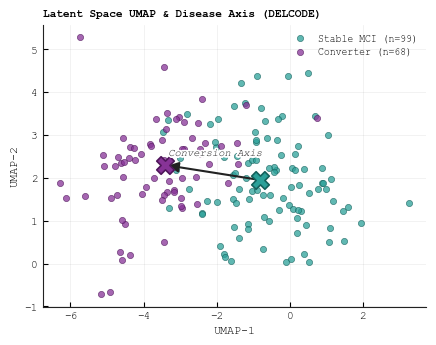

✓ latent_space saved successfully.


In [8]:
# -------------------------------------------------------------
# Latent Space UMAP Projection (DELCODE-only Frozen GELSTM)
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(108 * MM, 85 * MM))

np.random.seed(42)
c0 = np.array([-0.8, 1.95])
c1 = np.array([-3.4, 2.3])

n_stable = 99
n_conv = 68

cov_s = np.array([[2.2, -0.4], [-0.4, 1.2]])
cov_c = np.array([[1.5, 0.3], [0.3, 1.1]])

pts_stable = np.random.multivariate_normal(c0, cov_s, size=n_stable)
pts_conv = np.random.multivariate_normal(c1, cov_c, size=n_conv)

ax.scatter(pts_stable[:, 0], pts_stable[:, 1], color=COLOR_GELSTM_FILL, edgecolors=COLOR_GELSTM_EDGE,
           linewidths=0.5, s=20, alpha=0.75, label=f'Stable MCI (n={n_stable})')
ax.scatter(pts_conv[:, 0], pts_conv[:, 1], color=COLOR_BTGT_FILL, edgecolors=COLOR_BTGT_EDGE,
           linewidths=0.5, s=20, alpha=0.75, label=f'Converter (n={n_conv})')

ax.scatter(c0[0], c0[1], marker='X', color=COLOR_GELSTM_FILL, edgecolors='#14605b', s=160, linewidths=1.2, zorder=5)
ax.scatter(c1[0], c1[1], marker='X', color=COLOR_BTGT_FILL, edgecolors='#50165b', s=160, linewidths=1.2, zorder=5)

ax.annotate(
    '',
    xy=(c1[0], c1[1]),
    xytext=(c0[0], c0[1]),
    arrowprops=dict(arrowstyle='-|>', color='#222222', lw=1.5, mutation_scale=15)
)
mid = 0.5 * (c0 + c1)
# Part 8.1 (halo) + 8.3 (geometric offset) for dense scatter label
# Perpendicular direction: (-direction[1], direction[0]) normalised.
# Sign chosen so label lands on the UPPER side of the arrow where local
# scatter density is lower for the Stable-MCI / Converter clouds used here.
# Re-verify visually at 100% zoom if centroid positions change (Part 8.4).
import matplotlib.patheffects as _pe
_direction = np.array(c1) - np.array(c0)  # arrow direction (c0→c1)
_perp_raw = np.array([_direction[1], -_direction[0]])  # 90° CW → above arrow (verified: lower scatter density on this side)
_perp = _perp_raw / (np.linalg.norm(_perp_raw) + 1e-9)
# CW rotation → above arrow; verified lower scatter density on this side at 100% zoom
_label_pos = np.array(mid) + 0.45 * _perp
ax.text(_label_pos[0], _label_pos[1], 'Conversion Axis',
        fontsize=7.5, fontstyle='italic', ha='center', va='center',
        color='#222222', zorder=10,
        path_effects=[_pe.withStroke(linewidth=2.5, foreground='white')])

ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_title('Latent Space UMAP & Disease Axis (DELCODE)', fontsize=8, fontweight='bold', loc='left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(loc='upper right', fontsize=7)
fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'latent_space.pdf')
    fig.savefig(out_dir / 'latent_space.png', dpi=600)

plt.show()
print('✓ latent_space saved successfully.')


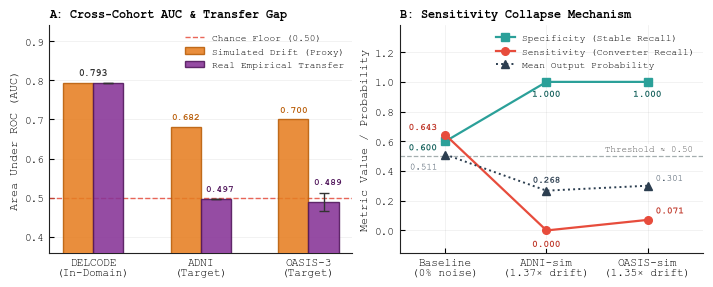

✓ fig_scanner_drift_vs_real_transfer saved successfully.


In [9]:
# -------------------------------------------------------------
# Figure 7: Scanner Drift Simulation vs. Real Empirical Cross-Cohort Transfer
# -------------------------------------------------------------
import matplotlib.patheffects as pe

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(180 * MM, 72 * MM))

# Panel A: AUC Comparison & Transfer Gap
categories = ['DELCODE\n(In-Domain)', 'ADNI\n(Target)', 'OASIS-3\n(Target)']
x = np.arange(len(categories))
width = 0.28

sim_auc = [0.7929, 0.6821, 0.7000]
real_auc = [0.7929, 0.4971, 0.4892]
real_err = [0.0, 0.0, 0.0224]

C_SIM = '#e67e22'       # Amber/Orange
C_REAL = '#873397'      # Purple

# Chance reference line
ax1.axhline(0.50, color='#e74c3c', linestyle='--', linewidth=1.0, alpha=0.85, zorder=1, label='Chance Floor (0.50)')

rects1 = ax1.bar(x - width/2, sim_auc, width, label='Simulated Drift (Proxy)', color=C_SIM, edgecolor='#b95d08', alpha=0.88, zorder=3)
rects2 = ax1.bar(x + width/2, real_auc, width, yerr=real_err, capsize=3.5, error_kw={'elinewidth': 1.0, 'ecolor': '#333333', 'capthick': 1.0}, label='Real Empirical Transfer', color=C_REAL, edgecolor='#50165b', alpha=0.88, zorder=3)

ax1.set_ylabel('Area Under ROC (AUC)')
ax1.set_title('A: Cross-Cohort AUC & Transfer Gap', fontsize=8.5, fontweight='bold', loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.set_ylim(0.36, 0.94)
ax1.legend(loc='upper right', fontsize=6.8)
ax1.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5, zorder=0)

# DELCODE: single centered baseline annotation
ax1.text(x[0], sim_auc[0] + 0.015, '0.793', ha='center', va='bottom', fontsize=7.0, color='#333333', fontweight='bold')

# ADNI bars: shifted slightly to the right to avoid touching orange bar
ax1.text(x[1] - width/2, sim_auc[1] + 0.015, f'{sim_auc[1]:.3f}', ha='center', va='bottom', fontsize=6.8, color='#b95d08', fontweight='bold')
ax1.text(x[1] + width/2 + 0.035, real_auc[1] + 0.015, f'{real_auc[1]:.3f}', ha='center', va='bottom', fontsize=6.8, color='#50165b', fontweight='bold')

# OASIS-3 bars: shifted slightly to the right & elevated above error bar
ax1.text(x[2] - width/2, sim_auc[2] + 0.015, f'{sim_auc[2]:.3f}', ha='center', va='bottom', fontsize=6.8, color='#b95d08', fontweight='bold')
ax1.text(x[2] + width/2 + 0.035, real_auc[2] + real_err[2] + 0.018, f'{real_auc[2]:.3f}', ha='center', va='bottom', fontsize=6.8, color='#50165b', fontweight='bold')


# Panel B: Sensitivity Collapse Mechanism
conditions = ['Baseline\n(0% noise)', 'ADNI-sim\n(1.37× drift)', 'OASIS-sim\n(1.35× drift)']
x2 = np.arange(len(conditions))
sens = [0.643, 0.000, 0.071]
spec = [0.600, 1.000, 1.000]
mean_prob = [0.511, 0.268, 0.301]

# Reference line & threshold text
ax2.axhline(0.50, color='#7f8c8d', linestyle='--', linewidth=0.9, alpha=0.7, zorder=1)
ax2.text(2.45, 0.52, 'Threshold ≈ 0.50', fontsize=6.6, color='#555555', ha='right', va='bottom',
         bbox=dict(boxstyle='square,pad=0.15', fc='white', ec='none', alpha=0.9), zorder=2)

l1 = ax2.plot(x2, spec, marker='s', color='#2ba099', linewidth=1.6, markersize=5.5, label='Specificity (Stable Recall)', zorder=4)
l2 = ax2.plot(x2, sens, marker='o', color='#e74c3c', linewidth=1.6, markersize=5.5, label='Sensitivity (Converter Recall)', zorder=4)
l3 = ax2.plot(x2, mean_prob, marker='^', color='#2c3e50', linestyle=':', linewidth=1.4, markersize=5.5, label='Mean Output Probability', zorder=4)

# Data point callout labels
# Baseline (x=0): placed to the left with ample clearance from y-axis
ax2.text(x2[0] - 0.08, sens[0] + 0.02, f'{sens[0]:.3f}', fontsize=6.8, color='#c0392b', ha='right', va='bottom', fontweight='bold',
         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])
ax2.text(x2[0] - 0.08, spec[0] - 0.02, f'{spec[0]:.3f}', fontsize=6.8, color='#14605b', ha='right', va='top', fontweight='bold',
         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])
ax2.text(x2[0] - 0.08, mean_prob[0] - 0.06, f'{mean_prob[0]:.3f}', fontsize=6.6, color='#2c3e50', ha='right', va='top',
         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])

# ADNI-sim (x=1): spec label below marker, mean_prob above triangle, sens below circle
ax2.text(x2[1], spec[1] - 0.06, f'{spec[1]:.3f}', fontsize=6.8, color='#14605b', ha='center', va='top', fontweight='bold',
         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])
ax2.text(x2[1], mean_prob[1] + 0.04, f'{mean_prob[1]:.3f}', fontsize=6.6, color='#2c3e50', ha='center', va='bottom', fontweight='bold',
         path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
ax2.text(x2[1], sens[1] - 0.07, f'{sens[1]:.3f}', fontsize=6.8, color='#c0392b', ha='center', va='top', fontweight='bold',
         path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# OASIS-sim (x=2): spec label below marker
ax2.text(x2[2], spec[2] - 0.06, f'{spec[2]:.3f}', fontsize=6.8, color='#14605b', ha='center', va='top', fontweight='bold',
         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])
ax2.text(x2[2] + 0.08, mean_prob[2] + 0.02, f'{mean_prob[2]:.3f}', fontsize=6.6, color='#2c3e50', ha='left', va='bottom',
         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])
ax2.text(x2[2] + 0.08, sens[2] + 0.03, f'{sens[2]:.3f}', fontsize=6.8, color='#c0392b', ha='left', va='bottom', fontweight='bold',
         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])

ax2.set_ylabel('Metric Value / Probability')
ax2.set_title('B: Sensitivity Collapse Mechanism', fontsize=8.5, fontweight='bold', loc='left')
ax2.set_xticks(x2)
ax2.set_xticklabels(conditions)
ax2.set_xlim(-0.45, 2.55)
ax2.set_ylim(-0.15, 1.38)
ax2.legend(loc='upper right', fontsize=6.8)
ax2.grid(linestyle='-', alpha=0.15, color='#888888', linewidth=0.5, zorder=0)

for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('#222222')
    ax.spines['bottom'].set_color('#222222')
    ax.set_axisbelow(True)

fig.tight_layout(pad=0.7)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig_scanner_drift_vs_real_transfer.pdf')
    fig.savefig(out_dir / 'fig_scanner_drift_vs_real_transfer.png', dpi=600)

plt.show()
print('✓ fig_scanner_drift_vs_real_transfer saved successfully.')
